In [2]:
import os
import scanpy as sc
from matplotlib import pyplot as plt

file_path = os.path.expanduser( "~/Downloads/6b3b10eb-11e7-4589-af2e-591d7401cfaa (1).h5ad")
adata_kidney_full = sc.read_h5ad(file_path)
print(adata_kidney_full)

AnnData object with n_obs × n_vars = 27675 × 26791
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampletype', 'CMVstatus', 'percent.mt', 'Group', 'Female', 'Male', 'sampleType', 'log10GenesPerUMI', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'percent.ribo', 'study_pi', 'sample_id', 'donor_id', 'protocol_url', 'institute', 'library_id', 'library_id_repository', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'assay_ontology_term_id', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'gene_annot

In [3]:
adata_kidney_non_enrich = adata_kidney_full[
    adata_kidney_full.obs["sample_id"].str.startswith("Total")
].copy()

In [4]:
print("n_cells:", adata_kidney_non_enrich.n_obs)
print("n_donors:", adata_kidney_non_enrich.obs["donor_id"].nunique())
print("n_samples:", adata_kidney_non_enrich.obs["sample_id"].nunique())
print(adata_kidney_non_enrich.obs["sample_id"].value_counts())

n_cells: 20778
n_donors: 9
n_samples: 9
sample_id
Total2    4738
Total4    3739
Total5    3280
Total3    2366
Total8    1894
Total7    1811
Total9    1264
Total1    1080
Total6     606
Name: count, dtype: int64


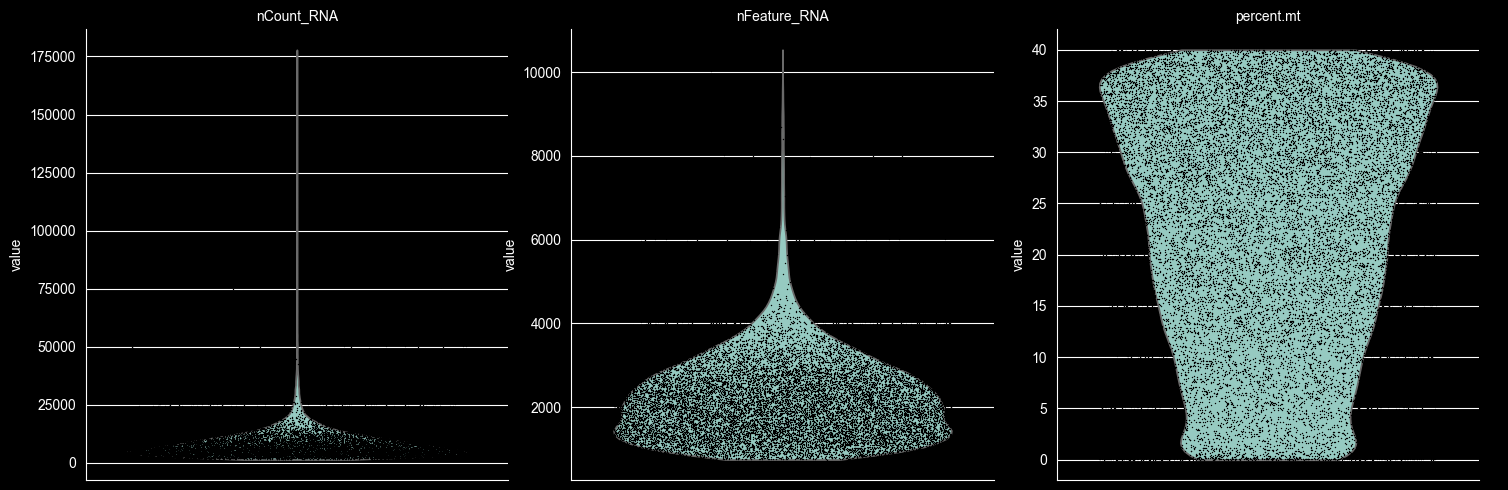

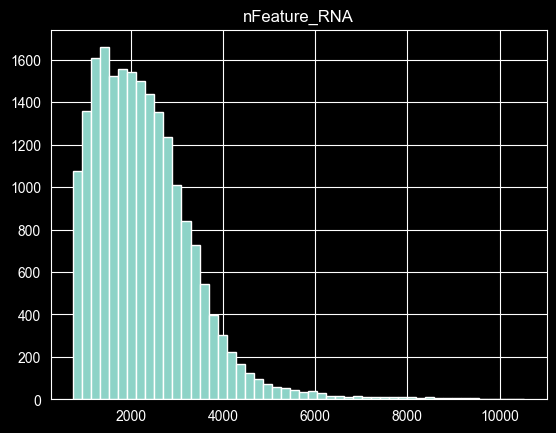

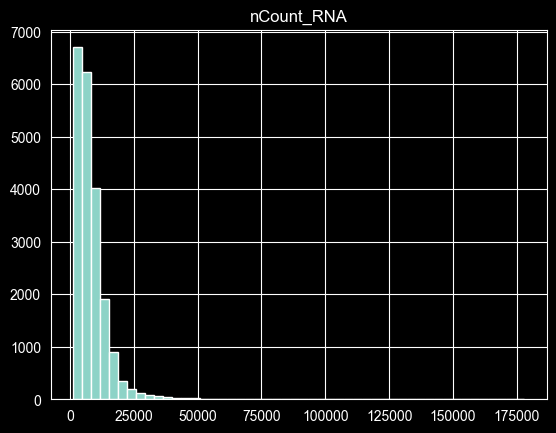

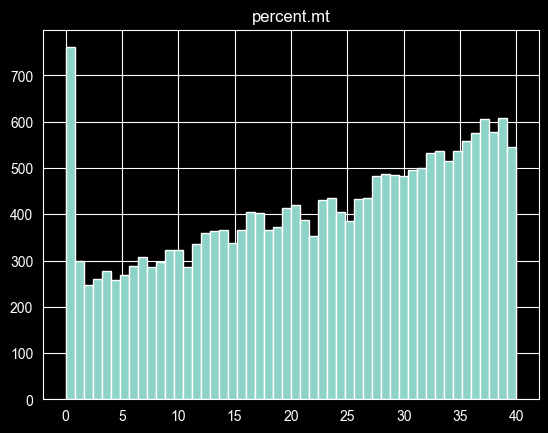

In [5]:
import matplotlib.pyplot as plt

sc.pl.violin(
    adata_kidney_non_enrich,
    keys=["nCount_RNA", "nFeature_RNA", "percent.mt"],
    jitter=0.4,
    multi_panel=True
)

adata_kidney_non_enrich.obs["nFeature_RNA"].hist(bins=50)
plt.title("nFeature_RNA")
plt.show()

adata_kidney_non_enrich.obs["nCount_RNA"].hist(bins=50)
plt.title("nCount_RNA")
plt.show()

adata_kidney_non_enrich.obs["percent.mt"].hist(bins=50)
plt.title("percent.mt")
plt.show()

In [8]:
adata_kidney_non_enrich_qc = adata_kidney_non_enrich[
    (adata_kidney_non_enrich.obs["nFeature_RNA"] >= 500) &
    (adata_kidney_non_enrich.obs["nCount_RNA"] >= 1500) &
    (adata_kidney_non_enrich.obs["nFeature_RNA"] <= 7000) &
    (adata_kidney_non_enrich.obs["nCount_RNA"] <= 40000) &
    (adata_kidney_non_enrich.obs["percent.mt"] < 38)
].copy()

print(adata_kidney_non_enrich_qc)
print("Cells kept:", adata_kidney_non_enrich_qc.n_obs)
print("Cells removed:", adata_kidney_non_enrich.n_obs - adata_kidney_non_enrich_qc.n_obs)
print("Proportion removed:", (adata_kidney_non_enrich.n_obs - adata_kidney_non_enrich_qc.n_obs) / adata_kidney_non_enrich.n_obs)

AnnData object with n_obs × n_vars = 19156 × 26791
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampletype', 'CMVstatus', 'percent.mt', 'Group', 'Female', 'Male', 'sampleType', 'log10GenesPerUMI', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'percent.ribo', 'study_pi', 'sample_id', 'donor_id', 'protocol_url', 'institute', 'library_id', 'library_id_repository', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'assay_ontology_term_id', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'gene_annot

In [9]:
adata_kidney_non_enrich_qc_r = adata_kidney_non_enrich_qc.copy()

adata_kidney_non_enrich_qc_r.layers["counts"] = (
    adata_kidney_non_enrich_qc_r.raw[:, adata_kidney_non_enrich_qc_r.var_names].X.copy()
)

print(adata_kidney_non_enrich_qc_r.shape)
print(adata_kidney_non_enrich_qc_r.layers["counts"].shape)

print(
    adata_kidney_non_enrich_qc_r.layers["counts"][:15, :15].toarray()
    if hasattr(adata_kidney_non_enrich_qc_r.layers["counts"][:15, :15], "toarray")
    else adata_kidney_non_enrich_qc_r.layers["counts"][:15, :15]
)

#adata_kidney_non_enrich_qc_r.write(
    #"/Users/meredithzhang/Desktop/adata_kidney_non_enrich_qc_r_with_counts.h5ad"
#)

(19156, 26791)
(19156, 26791)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [10]:
adata_kidney_non_enrich_qc_r.write(
    "/Users/meredithzhang/Desktop/adata_kidney_non_enrich_qc_r_with_counts.h5ad"
)

In [11]:
celltype_counts = adata_kidney_non_enrich_qc.obs["cell_type"].value_counts()
celltype_props = adata_kidney_non_enrich_qc.obs["cell_type"].value_counts(normalize=True)

print(celltype_counts)
print(celltype_props)

cell_type
epithelial cell of proximal tubule                                    16959
kidney loop of Henle descending limb epithelial cell                    833
kidney loop of Henle cortical thick ascending limb epithelial cell      382
kidney capillary endothelial cell                                       301
renal principal cell                                                    182
renal alpha-intercalated cell                                           162
renal beta-intercalated cell                                             76
mesangial cell                                                           67
kidney distal convoluted tubule epithelial cell                          44
kidney cortex collecting duct epithelial cell                            34
unknown                                                                  32
mononuclear phagocyte                                                    25
parietal epithelial cell                                                 19
ki

AnnData object with n_obs × n_vars = 19156 × 26791
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampletype', 'CMVstatus', 'percent.mt', 'Group', 'Female', 'Male', 'sampleType', 'log10GenesPerUMI', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'percent.ribo', 'study_pi', 'sample_id', 'donor_id', 'protocol_url', 'institute', 'library_id', 'library_id_repository', 'manner_of_death', 'sample_source', 'sex_ontology_term_id', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'assay_ontology_term_id', 'sequenced_fragment', 'sequencing_platform', 'is_primary_data', 'reference_genome', 'alignment_software', 'intron_inclusion', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'library_preparation_batch', 'library_sequencing_run', 'gene_annot

2026-05-12 11:44:44,751 - harmonypy - INFO - Running Harmony
2026-05-12 11:44:44,771 - harmonypy - INFO -   Parameters:
2026-05-12 11:44:44,772 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-12 11:44:44,774 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-12 11:44:44,776 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-12 11:44:44,777 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-12 11:44:44,779 - harmonypy - INFO -     nclust: 100
2026-05-12 11:44:44,780 - harmonypy - INFO -     block_size: 0.05
2026-05-12 11:44:44,780 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-12 11:44:44,782 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-12 11:44:44,784 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-12 11:44:44,786 - harmonypy - INFO -     verbose: True
2026-05-12 11:44:44,787 - harmonypy - INFO -     random_state: 0
2026-05-12 11:44:44,788 - harmonypy - INFO -   Data: 50 PCs × 19156 cells
2026-05-12 11:44:44,789 - har

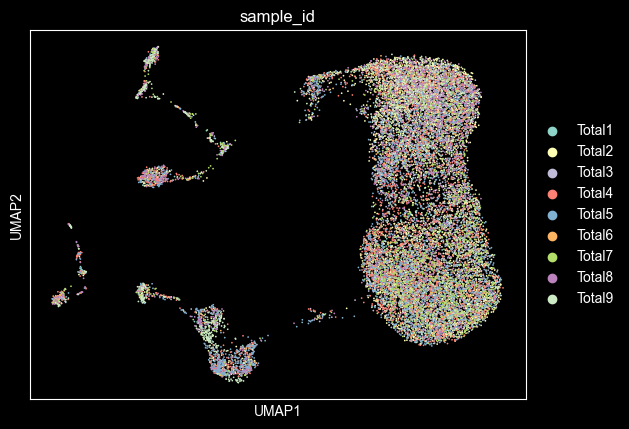

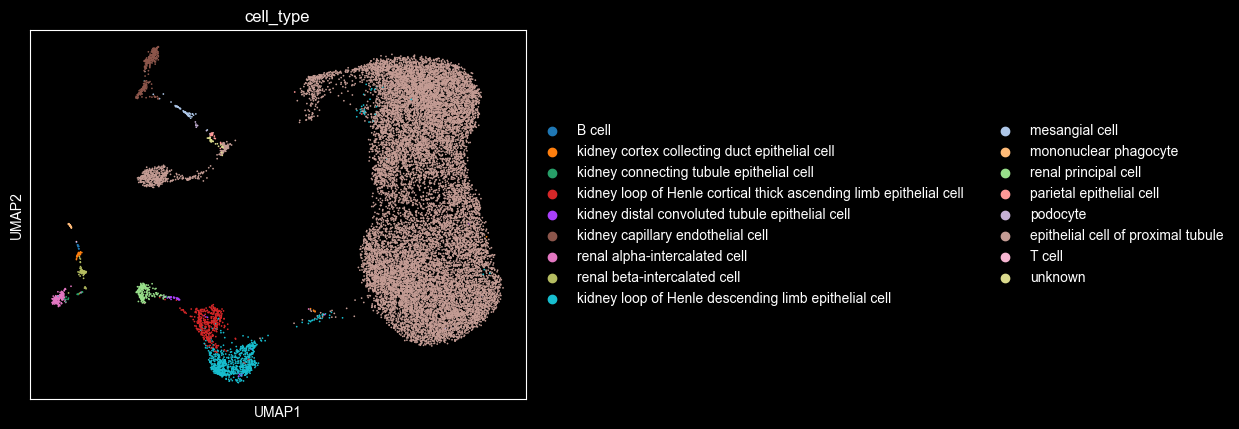

In [5]:
import os
import numpy as np
import scanpy as sc
import harmonypy as hm

file_path = os.path.expanduser("~/Desktop/adata_kidney_non_enrich_qc_r_with_counts.h5ad")
adata_kidney_non_enrich_qc_r = sc.read_h5ad(file_path)

print(adata_kidney_non_enrich_qc_r)

adata_kidney_harmony = adata_kidney_non_enrich_qc_r.copy()
adata_kidney_harmony.X = adata_kidney_harmony.layers["counts"].copy()

sc.pp.normalize_total(adata_kidney_harmony, target_sum=1e4)
sc.pp.log1p(adata_kidney_harmony)

sc.pp.highly_variable_genes(
    adata_kidney_harmony,
    flavor="seurat",
    batch_key="sample_id",
    n_top_genes=2000
)

adata_kidney_hvg = adata_kidney_harmony[:, adata_kidney_harmony.var["highly_variable"]].copy()

sc.tl.pca(adata_kidney_hvg)

ho = hm.run_harmony(
    adata_kidney_hvg.obsm["X_pca"],
    adata_kidney_hvg.obs,
    vars_use=["sample_id"]
)

adata_kidney_hvg.obsm["X_pca_harmony"] = np.array(ho.Z_corr)

sc.pp.neighbors(adata_kidney_hvg, use_rep="X_pca_harmony")
sc.tl.umap(adata_kidney_hvg, min_dist=0.3)
sc.tl.leiden(adata_kidney_hvg, resolution=0.5)

sc.pl.umap(adata_kidney_hvg, color="sample_id")
sc.pl.umap(adata_kidney_hvg, color="cell_type")

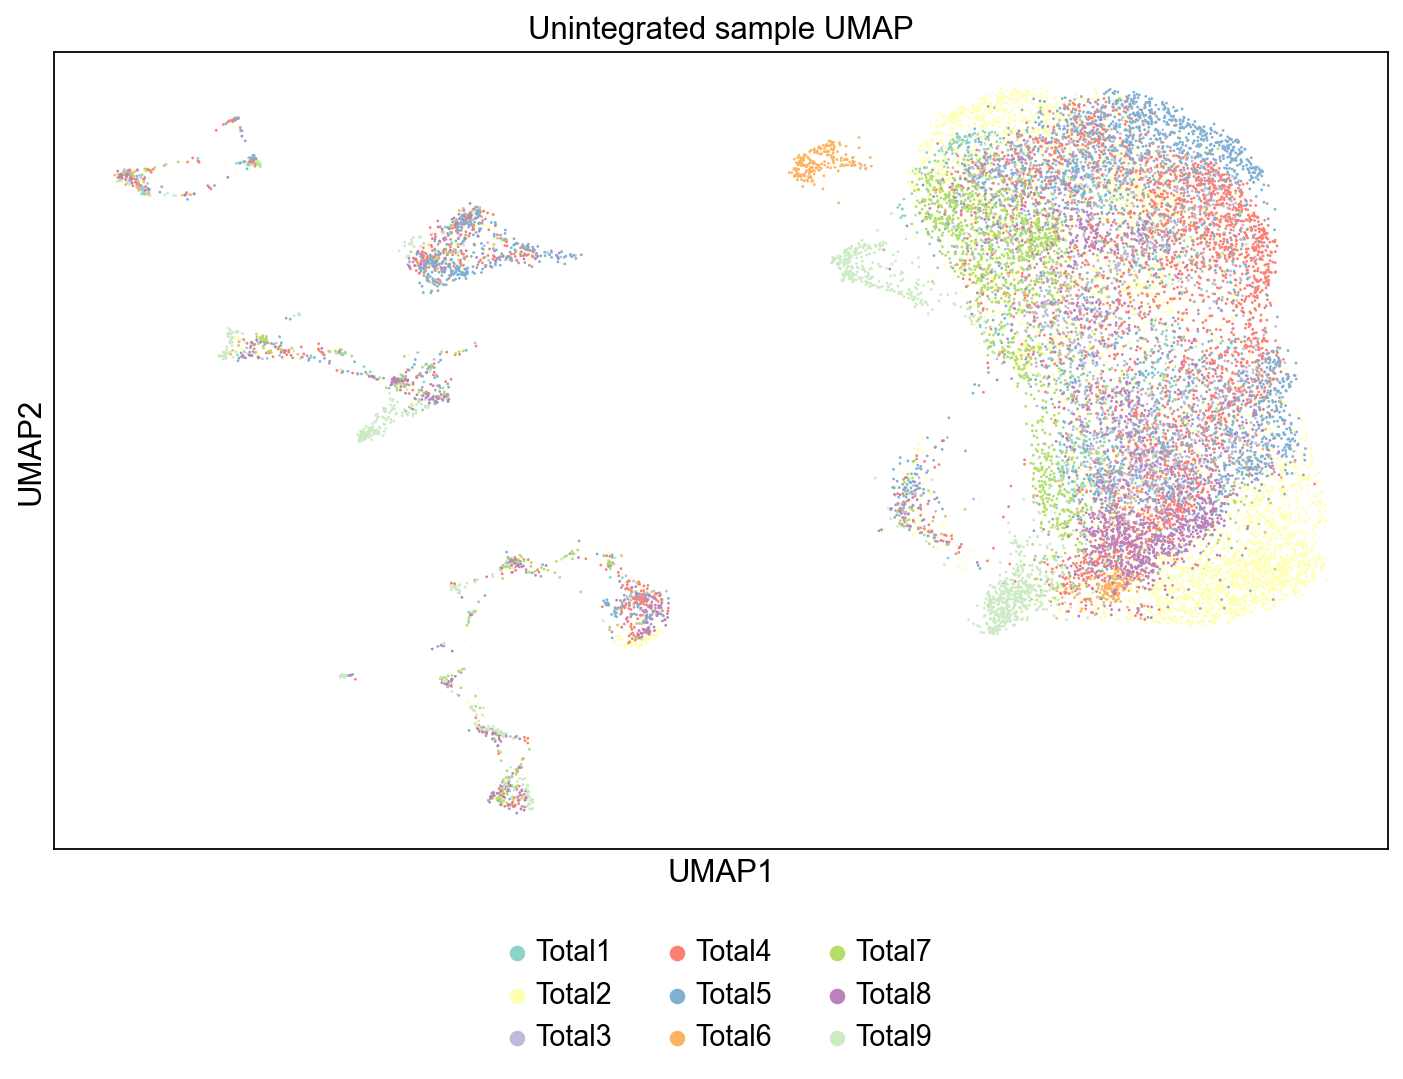

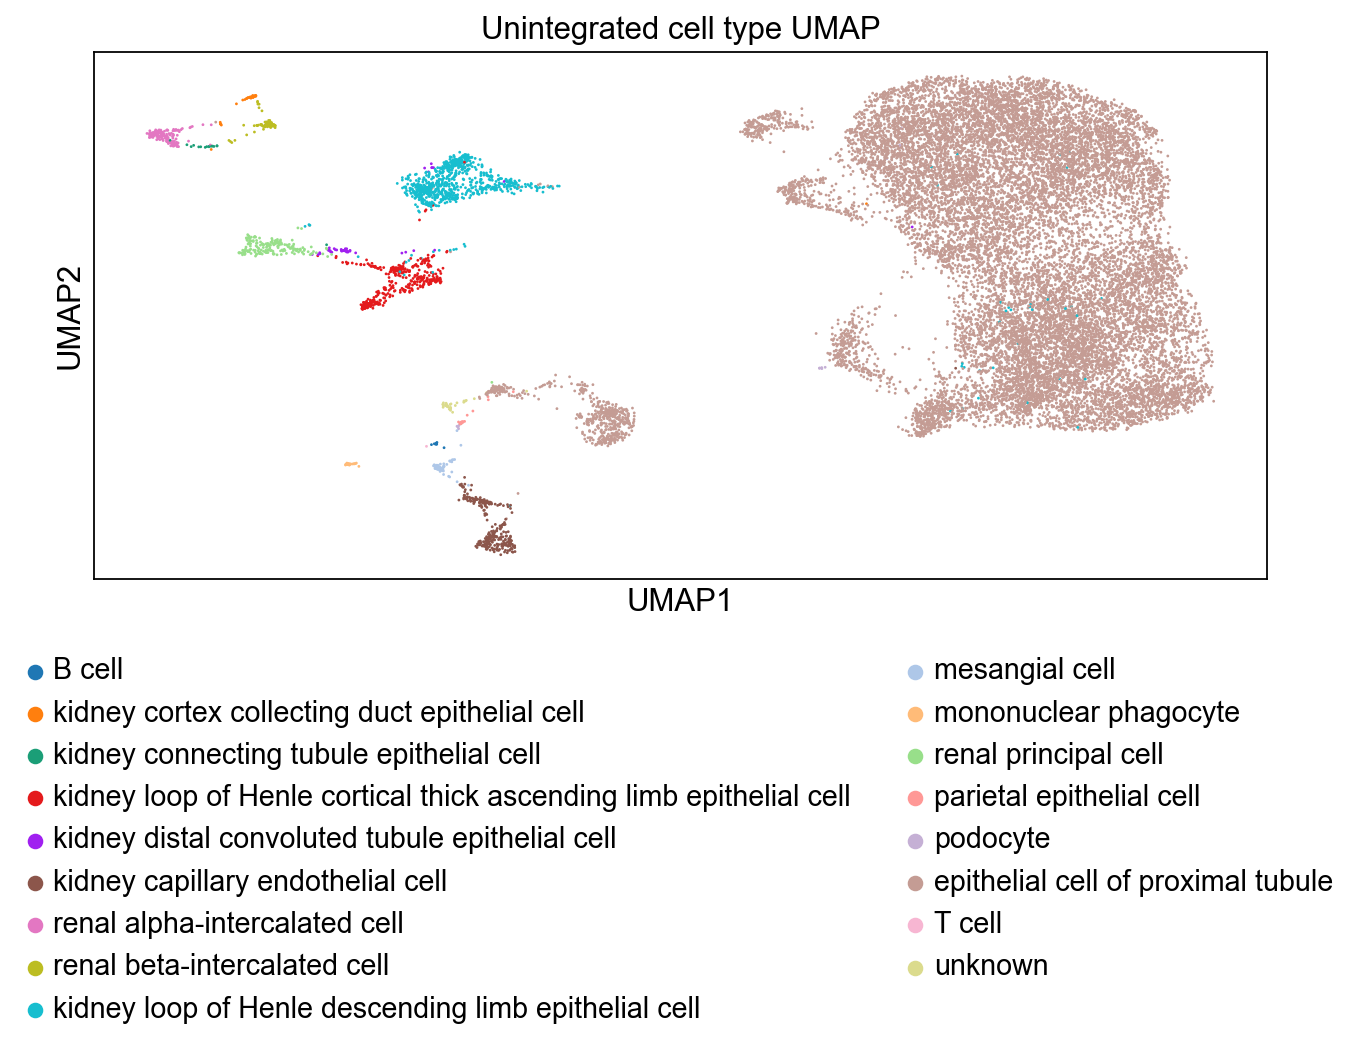

In [12]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(facecolor="white")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

adata_kidney_hvg.obs["sample_id"] = adata_kidney_hvg.obs["sample_id"].astype("category")
adata_kidney_hvg.obs["cell_type"] = adata_kidney_hvg.obs["cell_type"].astype("category")

sc.pp.neighbors(adata_kidney_hvg, use_rep="X_pca")
sc.tl.umap(adata_kidney_hvg, min_dist=0.3)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_hvg,
    color="sample_id",
    title="Unintegrated sample UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("Unintegrated sample UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_hvg,
    color="cell_type",
    title="Unintegrated cell type UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("Unintegrated cell type UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

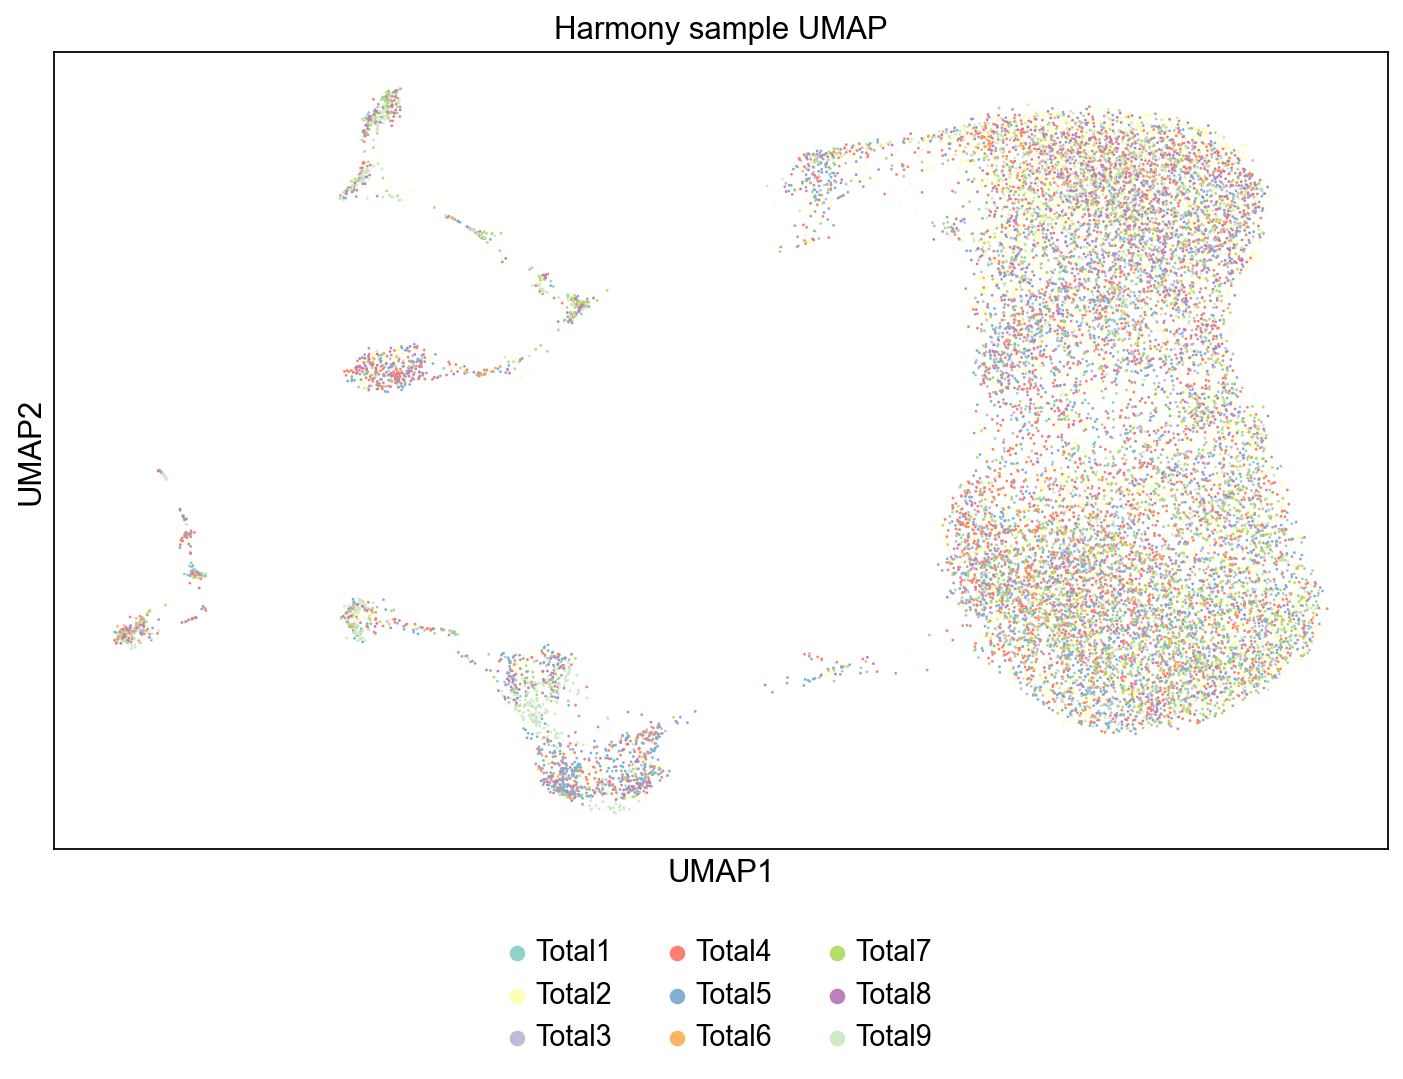

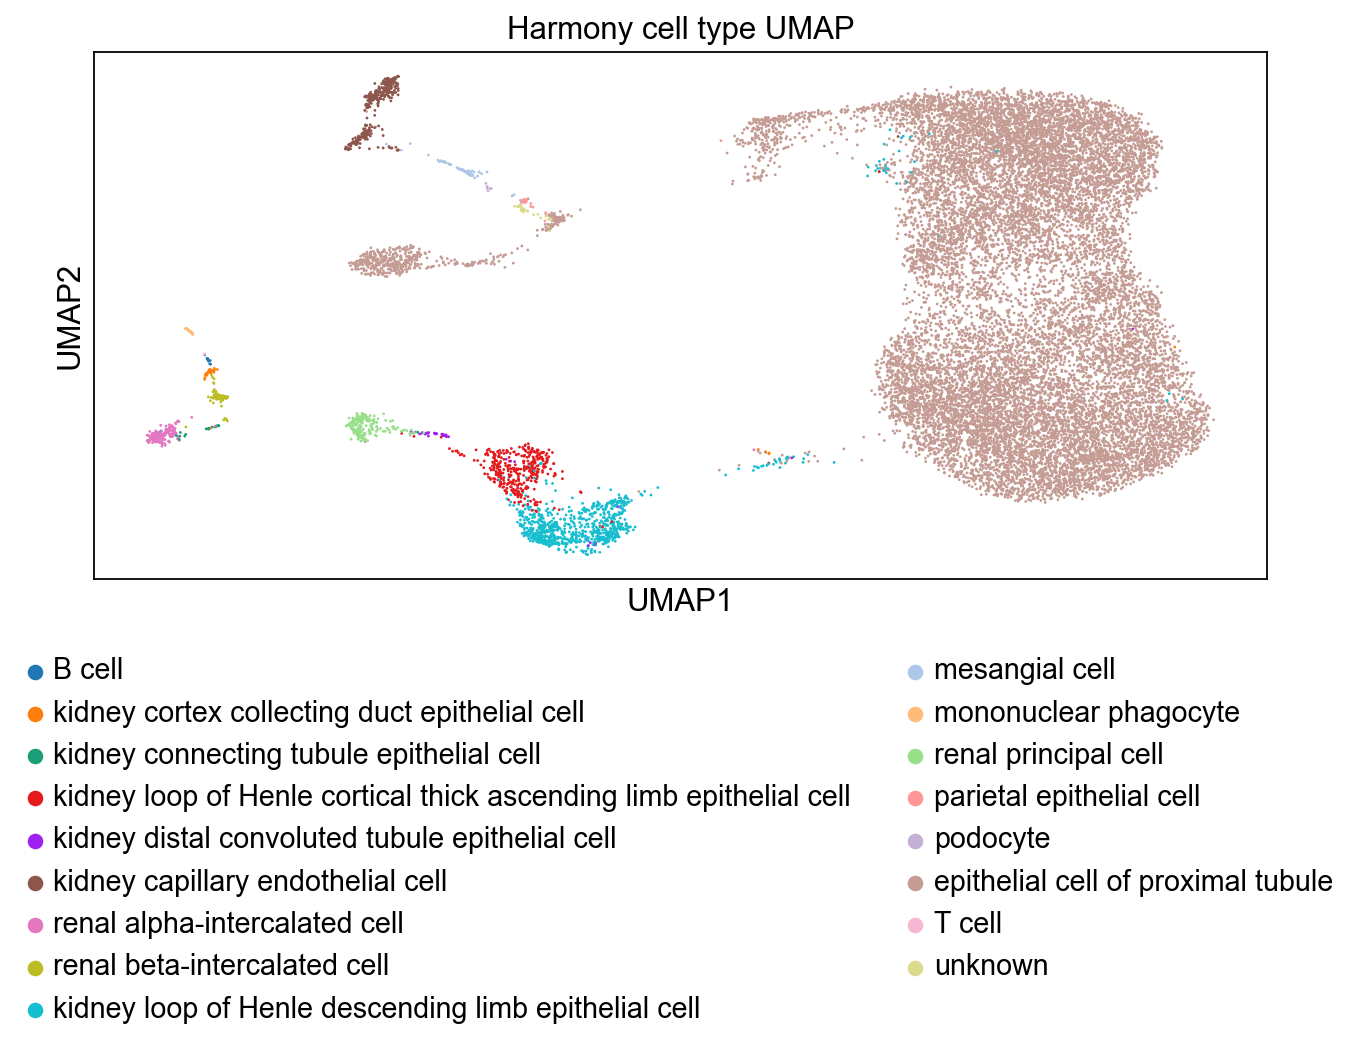

In [9]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(facecolor="white")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

adata_kidney_hvg.obs["sample_id"] = adata_kidney_hvg.obs["sample_id"].astype("category")
adata_kidney_hvg.obs["cell_type"] = adata_kidney_hvg.obs["cell_type"].astype("category")

batch_color_map = {
    "Total1": "#8dd3c7",
    "Total2": "#ffffb3",
    "Total3": "#bebada",
    "Total4": "#fb8072",
    "Total5": "#80b1d3",
    "Total6": "#fdb462",
    "Total7": "#b3de69",
    "Total8": "#bc80bd",
    "Total9": "#ccebc5"
}

celltype_color_map = {
    "B cell": "#1f77b4",
    "kidney cortex collecting duct epithelial cell": "#ff7f0e",
    "kidney connecting tubule epithelial cell": "#1b9e77",
    "kidney loop of Henle cortical thick ascending limb epithelial cell": "#e41a1c",
    "kidney distal convoluted tubule epithelial cell": "#a020f0",
    "kidney capillary endothelial cell": "#8c564b",
    "renal alpha-intercalated cell": "#e377c2",
    "renal beta-intercalated cell": "#bcbd22",
    "kidney loop of Henle descending limb epithelial cell": "#17becf",
    "mesangial cell": "#aec7e8",
    "mononuclear phagocyte": "#ffbb78",
    "renal principal cell": "#98df8a",
    "parietal epithelial cell": "#ff9896",
    "podocyte": "#c5b0d5",
    "epithelial cell of proximal tubule": "#c49c94",
    "T cell": "#f7b6d2",
    "unknown": "#dbdb8d"
}

adata_kidney_hvg.uns["sample_id_colors"] = [
    batch_color_map[x] for x in adata_kidney_hvg.obs["sample_id"].cat.categories
]

adata_kidney_hvg.uns["cell_type_colors"] = [
    celltype_color_map[x] for x in adata_kidney_hvg.obs["cell_type"].cat.categories
]

sc.pp.neighbors(adata_kidney_hvg, use_rep="X_pca_harmony")
sc.tl.umap(adata_kidney_hvg, min_dist=0.3)
sc.tl.leiden(adata_kidney_hvg, resolution=0.5)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_hvg,
    color="sample_id",
    title="Harmony batch UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("Harmony sample UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_hvg,
    color="cell_type",
    title="Harmony cell type UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("Harmony cell type UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

In [3]:
import scib_metrics as sm
from scib_metrics.nearest_neighbors import pynndescent
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

X_harmony = adata_kidney_hvg.obsm["X_pca_harmony"]

nn_harmony = pynndescent(
    X_harmony,
    n_neighbors=30,
    random_state=0
)

ilisi = sm.ilisi_knn(
    nn_harmony,
    adata_kidney_hvg.obs["sample_id"].to_numpy(),
    scale=True
)

clisi = sm.clisi_knn(
    nn_harmony,
    adata_kidney_hvg.obs["cell_type"].to_numpy(),
    scale=True
)

ari = adjusted_rand_score(
    adata_kidney_hvg.obs["cell_type"],
    adata_kidney_hvg.obs["leiden"]
)

nmi = normalized_mutual_info_score(
    adata_kidney_hvg.obs["cell_type"],
    adata_kidney_hvg.obs["leiden"]
)

print("iLISI:", ilisi)
print("cLISI:", clisi)
print("ARI:", ari)
print("NMI:", nmi)
#harmony

iLISI: 0.25395048
cLISI: 1.0
ARI: 0.09462758560939816
NMI: 0.36601782662772403


In [1]:
import os
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import scib_metrics as sm
from scib_metrics.nearest_neighbors import pynndescent
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

file_path = os.path.expanduser("~/Desktop/adata_kidney_non_enrich_qc_r_with_counts.h5ad")
adata_kidney_non_enrich_qc_r = sc.read_h5ad(file_path)

adata_kidney_scvi = adata_kidney_non_enrich_qc_r.copy()

scvi.settings.seed = 0

scvi.model.SCVI.setup_anndata(
    adata_kidney_scvi,
    layer="counts",
    batch_key="sample_id"
)

model = scvi.model.SCVI(
    adata_kidney_scvi,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb"
)

model.train()

SCVI_LATENT_KEY = "X_scVI"
adata_kidney_scvi.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

sc.pp.neighbors(adata_kidney_scvi, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_kidney_scvi, resolution=0.5)
sc.tl.umap(adata_kidney_scvi, min_dist=0.3)

adata_kidney_scvi.write(
    os.path.expanduser("~/Desktop/adata_kidney_non_enrich_scvi_result.h5ad")
)

/Users/meredithzhang/PHP2691hw/PythonProject6/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 0
/Users/meredithzhang/PHP2691hw/PythonProject6/.venv/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/meredithzhang/PHP2691hw/PythonProject6/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡

Epoch 400/400: 100%|██████████| 400/400 [1:22:11<00:00, 11.88s/it, v_num=1, train_loss=6.21e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [1:22:11<00:00, 12.33s/it, v_num=1, train_loss=6.21e+3]


/var/folders/3w/yklb0sxs0ss499k2l0cb08z80000gn/T/ipykernel_96783/3437418968.py:37: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_kidney_scvi, resolution=0.5)


In [2]:
X_scvi = adata_kidney_scvi.obsm["X_scVI"]

nn_scvi = pynndescent(
    X_scvi,
    n_neighbors=30,
    random_state=0
)

ilisi = sm.ilisi_knn(
    nn_scvi,
    adata_kidney_scvi.obs["sample_id"].to_numpy(),
    scale=True
)

clisi = sm.clisi_knn(
    nn_scvi,
    adata_kidney_scvi.obs["cell_type"].to_numpy(),
    scale=True
)

ari = adjusted_rand_score(
    adata_kidney_scvi.obs["cell_type"],
    adata_kidney_scvi.obs["leiden"]
)

nmi = normalized_mutual_info_score(
    adata_kidney_scvi.obs["cell_type"],
    adata_kidney_scvi.obs["leiden"]
)

print("iLISI:", ilisi)
print("cLISI:", clisi)
print("ARI:", ari)
print("NMI:", nmi)
#scvi

iLISI: 0.23831177
cLISI: 1.0
ARI: 0.17712000565754263
NMI: 0.4445019267354452


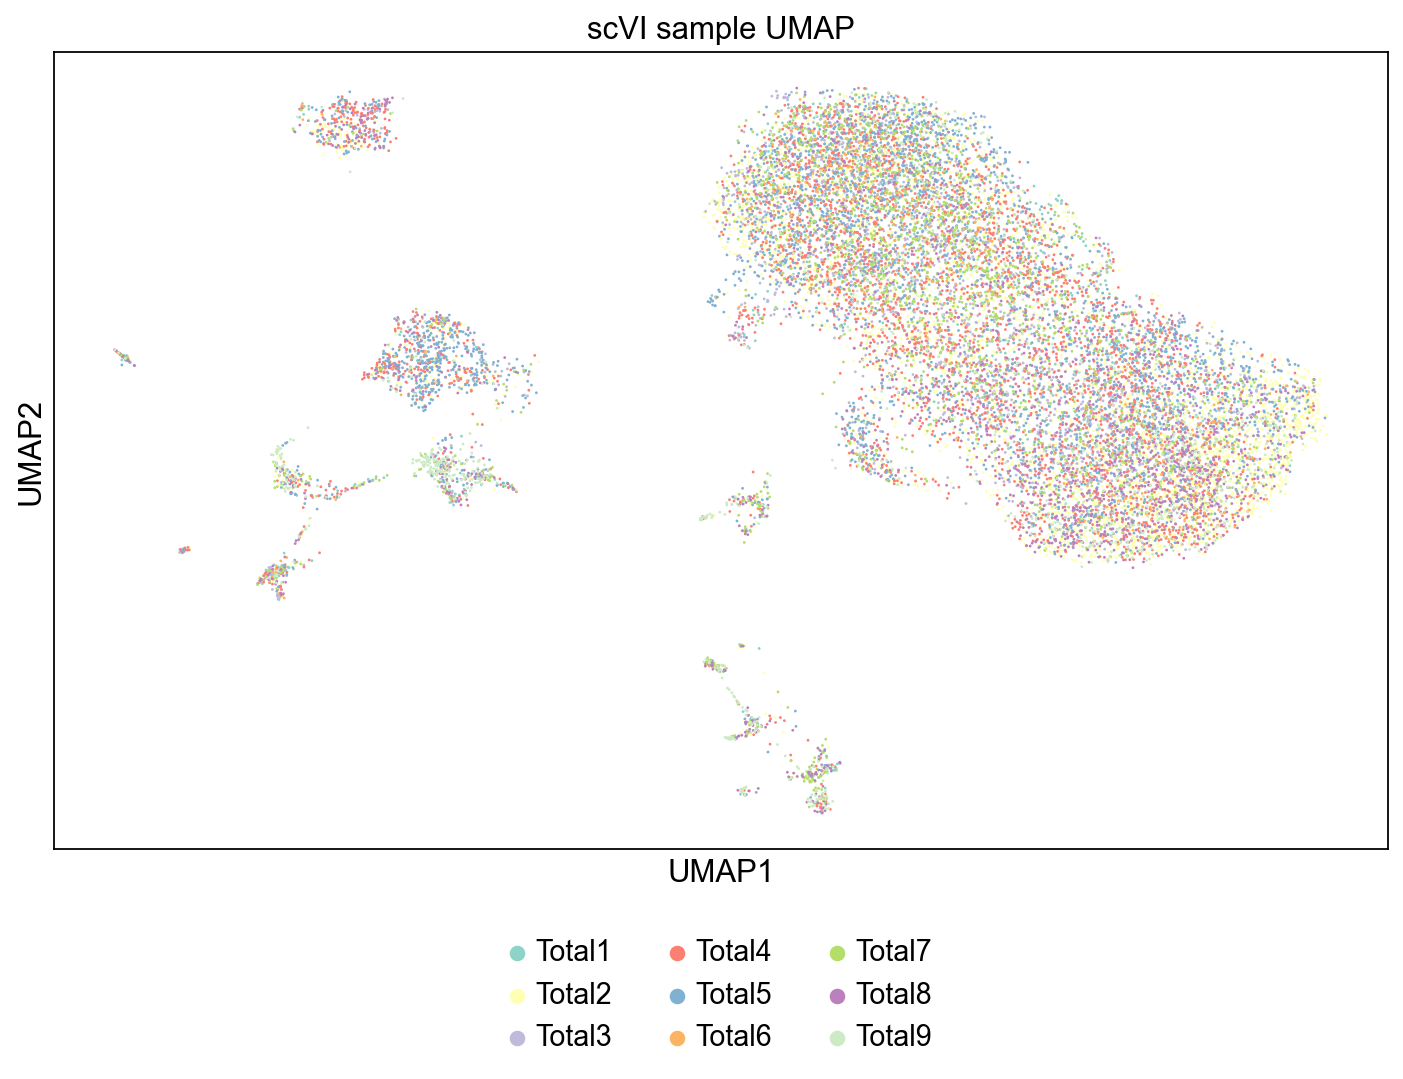

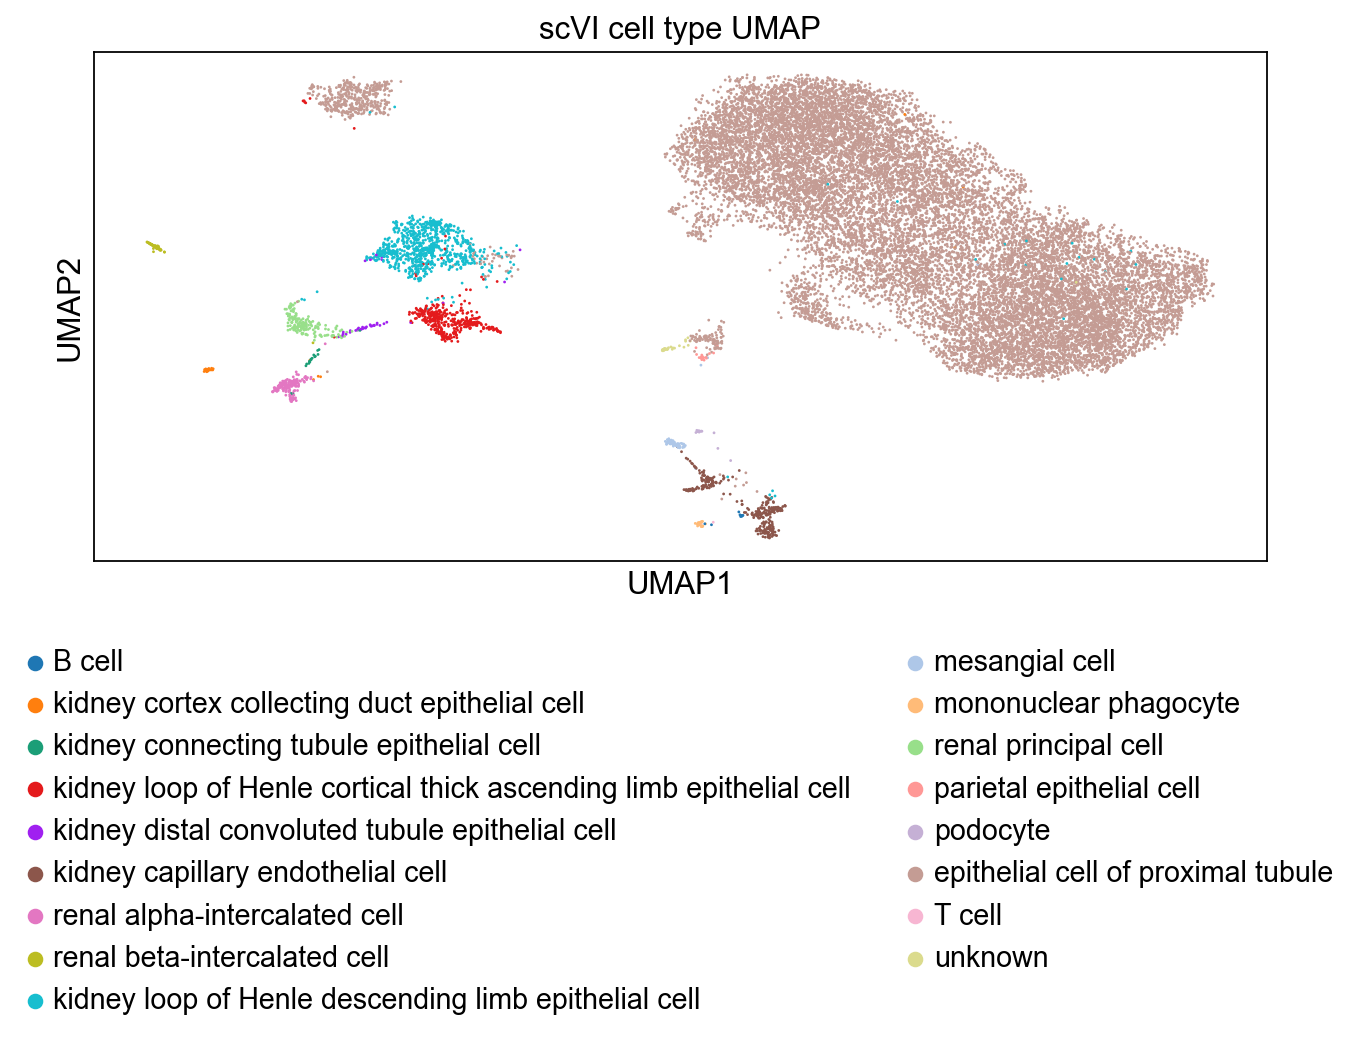

In [13]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

file_path = os.path.expanduser("~/Desktop/adata_kidney_non_enrich_scvi_result.h5ad")
adata_kidney_scvi = sc.read_h5ad(file_path)

sc.set_figure_params(facecolor="white")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

adata_kidney_scvi.obs["sample_id"] = adata_kidney_scvi.obs["sample_id"].astype("category")
adata_kidney_scvi.obs["cell_type"] = adata_kidney_scvi.obs["cell_type"].astype("category")

batch_color_map = {
    "Total1": "#8dd3c7",
    "Total2": "#ffffb3",
    "Total3": "#bebada",
    "Total4": "#fb8072",
    "Total5": "#80b1d3",
    "Total6": "#fdb462",
    "Total7": "#b3de69",
    "Total8": "#bc80bd",
    "Total9": "#ccebc5"
}

celltype_color_map = {
    "B cell": "#1f77b4",
    "kidney cortex collecting duct epithelial cell": "#ff7f0e",
    "kidney connecting tubule epithelial cell": "#1b9e77",
    "kidney loop of Henle cortical thick ascending limb epithelial cell": "#e41a1c",
    "kidney distal convoluted tubule epithelial cell": "#a020f0",
    "kidney capillary endothelial cell": "#8c564b",
    "renal alpha-intercalated cell": "#e377c2",
    "renal beta-intercalated cell": "#bcbd22",
    "kidney loop of Henle descending limb epithelial cell": "#17becf",
    "mesangial cell": "#aec7e8",
    "mononuclear phagocyte": "#ffbb78",
    "renal principal cell": "#98df8a",
    "parietal epithelial cell": "#ff9896",
    "podocyte": "#c5b0d5",
    "epithelial cell of proximal tubule": "#c49c94",
    "T cell": "#f7b6d2",
    "unknown": "#dbdb8d"
}

adata_kidney_scvi.uns["sample_id_colors"] = [
    batch_color_map[x] for x in adata_kidney_scvi.obs["sample_id"].cat.categories
]

adata_kidney_scvi.uns["cell_type_colors"] = [
    celltype_color_map[x] for x in adata_kidney_scvi.obs["cell_type"].cat.categories
]

sc.pp.neighbors(adata_kidney_scvi, use_rep="X_scVI")
sc.tl.umap(adata_kidney_scvi, min_dist=0.3)
sc.tl.leiden(adata_kidney_scvi, resolution=0.5)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_scvi,
    color="sample_id",
    title="scVI sample UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("scVI sample UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_scvi,
    color="cell_type",
    title="scVI cell type UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("scVI cell type UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

In [1]:
import os
import scanpy as sc
import scib_metrics as sm
from scib_metrics.nearest_neighbors import pynndescent
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

file_path = os.path.expanduser("~/Desktop/kidney.integrated_nonenrich.h5ad")
adata_kidney_seurat = sc.read_h5ad(file_path)
batch_col = "sample_id"
celltype_col = "cell_type"
cluster_col = "seurat_clusters"

# ARI / NMI
ari_seurat_kidney = adjusted_rand_score(
    adata_kidney_seurat.obs[celltype_col],
    adata_kidney_seurat.obs[cluster_col]
)

nmi_seurat_kidney = normalized_mutual_info_score(
    adata_kidney_seurat.obs[celltype_col],
    adata_kidney_seurat.obs[cluster_col]
)

# iLISI / cLISI
X_seurat_kidney = adata_kidney_seurat.obsm["X_pca"]

batch_labels_seurat_kidney = adata_kidney_seurat.obs[batch_col].to_numpy()
cell_labels_seurat_kidney = adata_kidney_seurat.obs[celltype_col].to_numpy()

nn_seurat_kidney = pynndescent(
    X_seurat_kidney,
    n_neighbors=30,
    random_state=0
)

ilisi_seurat_kidney = sm.ilisi_knn(
    nn_seurat_kidney,
    batch_labels_seurat_kidney,
    scale=True
)

clisi_seurat_kidney = sm.clisi_knn(
    nn_seurat_kidney,
    cell_labels_seurat_kidney,
    scale=True
)

results_seurat_kidney = {
    "method": "Seurat",
    "dataset": "kidney_non_enriched",
    "iLISI": float(ilisi_seurat_kidney),
    "cLISI": float(clisi_seurat_kidney),
    "ARI": float(ari_seurat_kidney),
    "NMI": float(nmi_seurat_kidney)
}

print(results_seurat_kidney)

/Users/meredithzhang/PHP2691hw/PythonProject6/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/meredithzhang/PHP2691hw/PythonProject6/.venv/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


{'method': 'Seurat', 'dataset': 'kidney_non_enriched', 'iLISI': 0.2672799229621887, 'cLISI': 1.0, 'ARI': 0.06808669473066935, 'NMI': 0.3553333275641123}


/Users/meredithzhang/PHP2691hw/PythonProject6/.venv/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


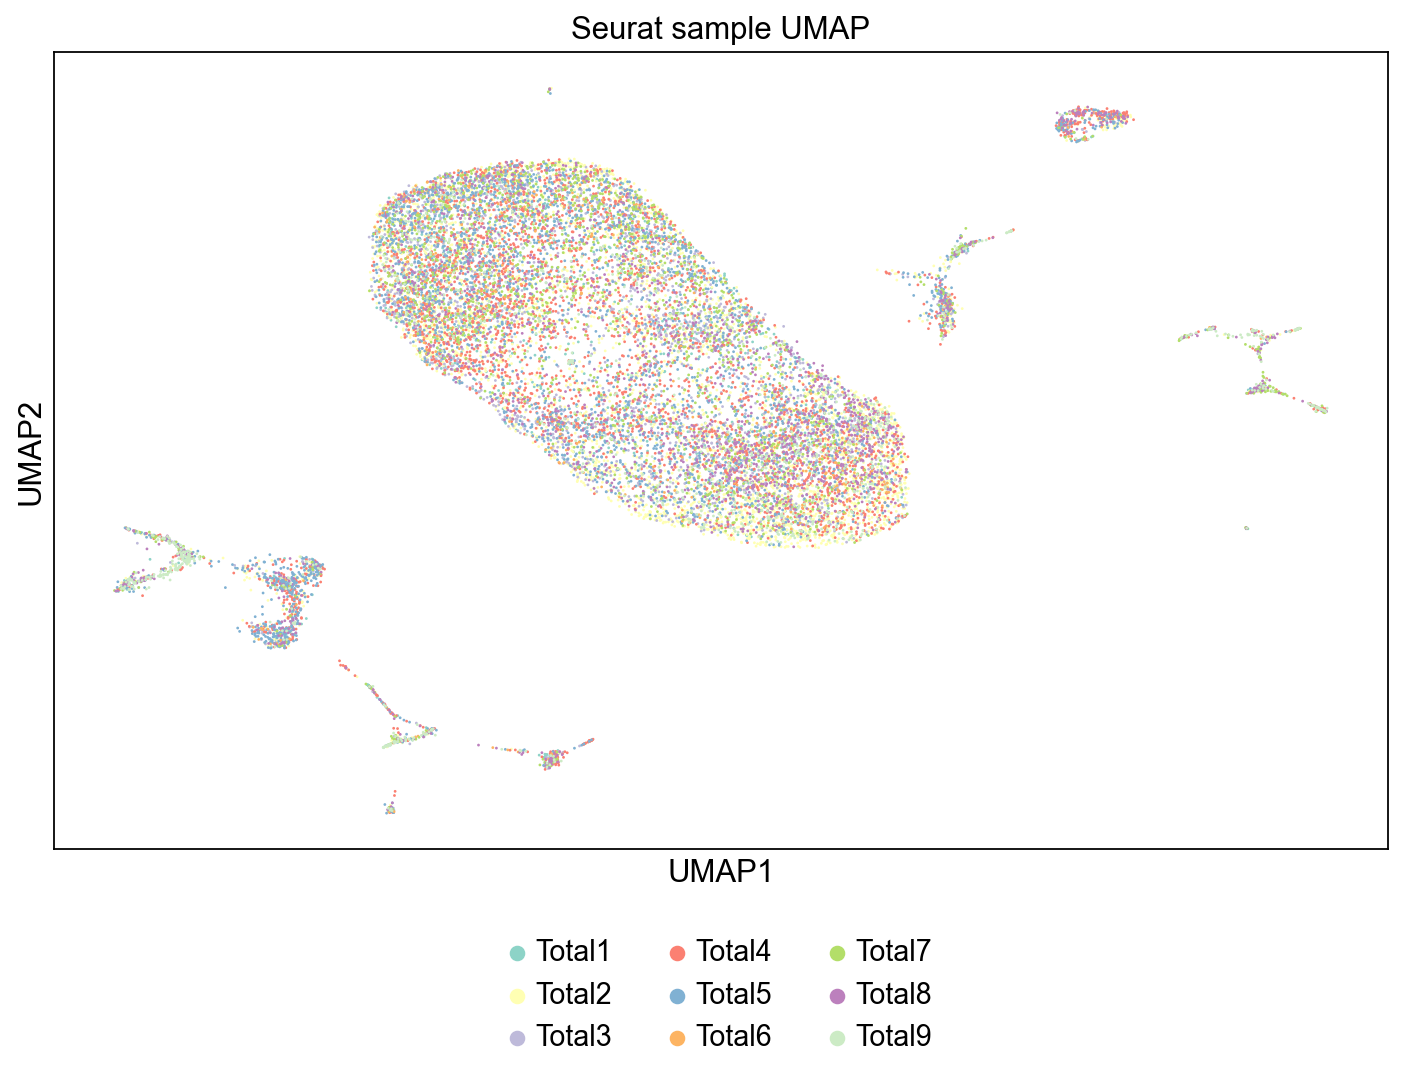

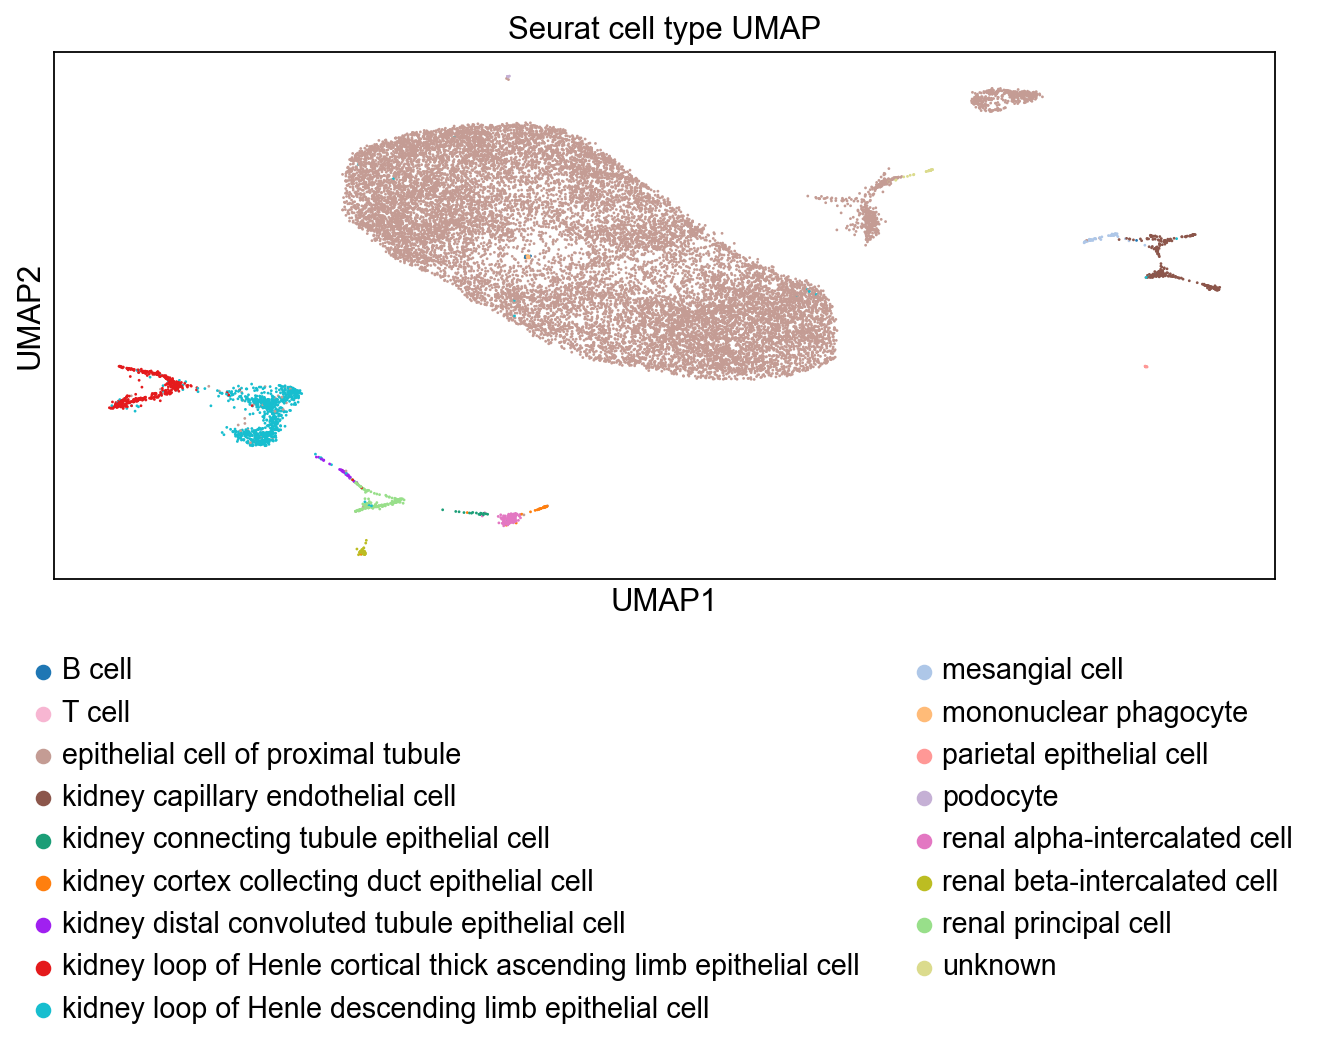

In [10]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

file_path = os.path.expanduser("~/Desktop/kidney.integrated_nonenrich.h5ad")
adata_kidney_seurat = sc.read_h5ad(file_path)

sc.set_figure_params(facecolor="white")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

adata_kidney_seurat.obs["sample_id"] = adata_kidney_seurat.obs["sample_id"].astype("category")
adata_kidney_seurat.obs["cell_type"] = adata_kidney_seurat.obs["cell_type"].astype("category")


adata_kidney_seurat.uns["sample_id_colors"] = [
    batch_color_map[x] for x in adata_kidney_seurat.obs["sample_id"].cat.categories
]

adata_kidney_seurat.uns["cell_type_colors"] = [
    celltype_color_map[x] for x in adata_kidney_seurat.obs["cell_type"].cat.categories
]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_seurat,
    color="sample_id",
    title="Seurat sample UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("Seurat sample UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

# cell type UMAP
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_kidney_seurat,
    color="cell_type",
    title="Seurat cell type UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("Seurat cell type UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

In [4]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
import scib_metrics as sm
from scib_metrics.nearest_neighbors import pynndescent
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

corrected_path = os.path.expanduser("~/Desktop/kidney_non_enrich_fastmnn_corrected.csv")
meta_path = os.path.expanduser("~/Desktop/kidney_non_enrich_fastmnn_metadata.csv")

corrected_df = pd.read_csv(corrected_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)
meta_df = meta_df.loc[corrected_df.index]

adata_fastmnn = ad.AnnData(
    X=corrected_df.values,
    obs=meta_df.copy()
)

adata_fastmnn.obs_names = corrected_df.index.astype(str)
adata_fastmnn.obsm["X_fastmnn"] = corrected_df.values

sc.pp.neighbors(
    adata_fastmnn,
    use_rep="X_fastmnn"
)

sc.tl.leiden(adata_fastmnn, resolution=0.5)

ari_fastmnn = adjusted_rand_score(
    adata_fastmnn.obs["cell_type"],
    adata_fastmnn.obs["leiden"]
)

nmi_fastmnn = normalized_mutual_info_score(
    adata_fastmnn.obs["cell_type"],
    adata_fastmnn.obs["leiden"]
)

nn_fastmnn = pynndescent(
    adata_fastmnn.obsm["X_fastmnn"],
    n_neighbors=30,
    random_state=0
)

ilisi_fastmnn = sm.ilisi_knn(
    nn_fastmnn,
    adata_fastmnn.obs["sample_id"].to_numpy(),
    scale=True
)

clisi_fastmnn = sm.clisi_knn(
    nn_fastmnn,
    adata_fastmnn.obs["cell_type"].to_numpy(),
    scale=True
)

results_fastmnn_kidney = {
    "method": "fastMNN",
    "dataset": "kidney_non_enriched",
    "iLISI": float(ilisi_fastmnn),
    "cLISI": float(clisi_fastmnn),
    "ARI": float(ari_fastmnn),
    "NMI": float(nmi_fastmnn)
}

print(results_fastmnn_kidney)

/var/folders/3w/yklb0sxs0ss499k2l0cb08z80000gn/T/ipykernel_10128/1775468112.py:29: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_fastmnn, resolution=0.5)


{'method': 'fastMNN', 'dataset': 'kidney_non_enriched', 'iLISI': 0.20827379822731018, 'cLISI': 1.0, 'ARI': 0.0803363170582983, 'NMI': 0.3687695896300286}


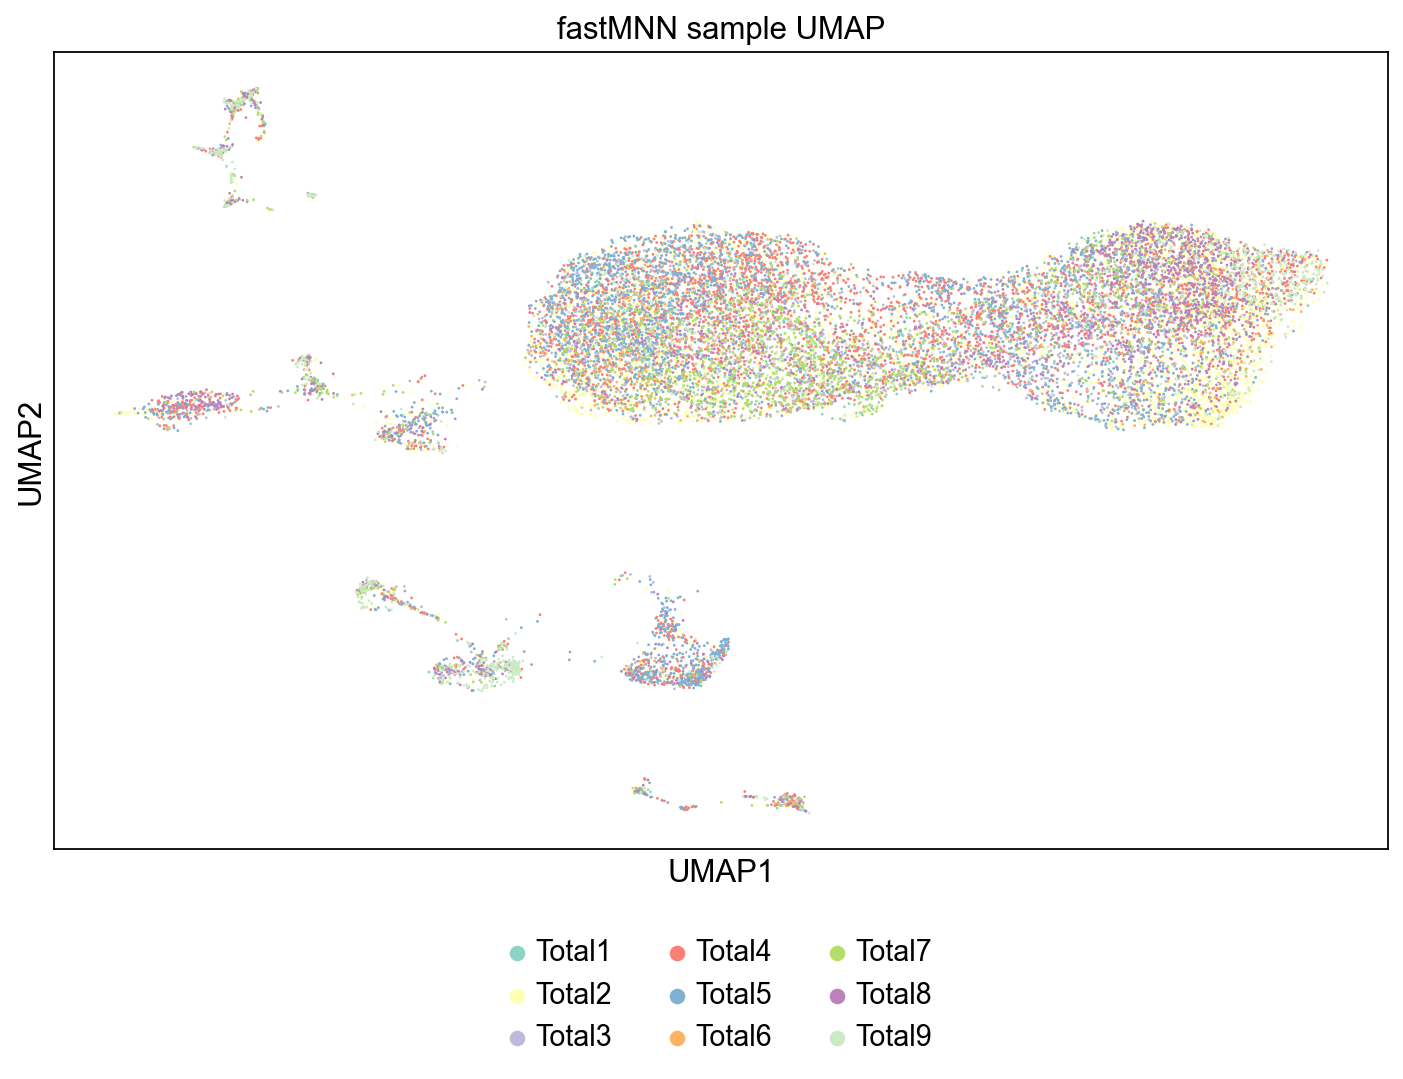

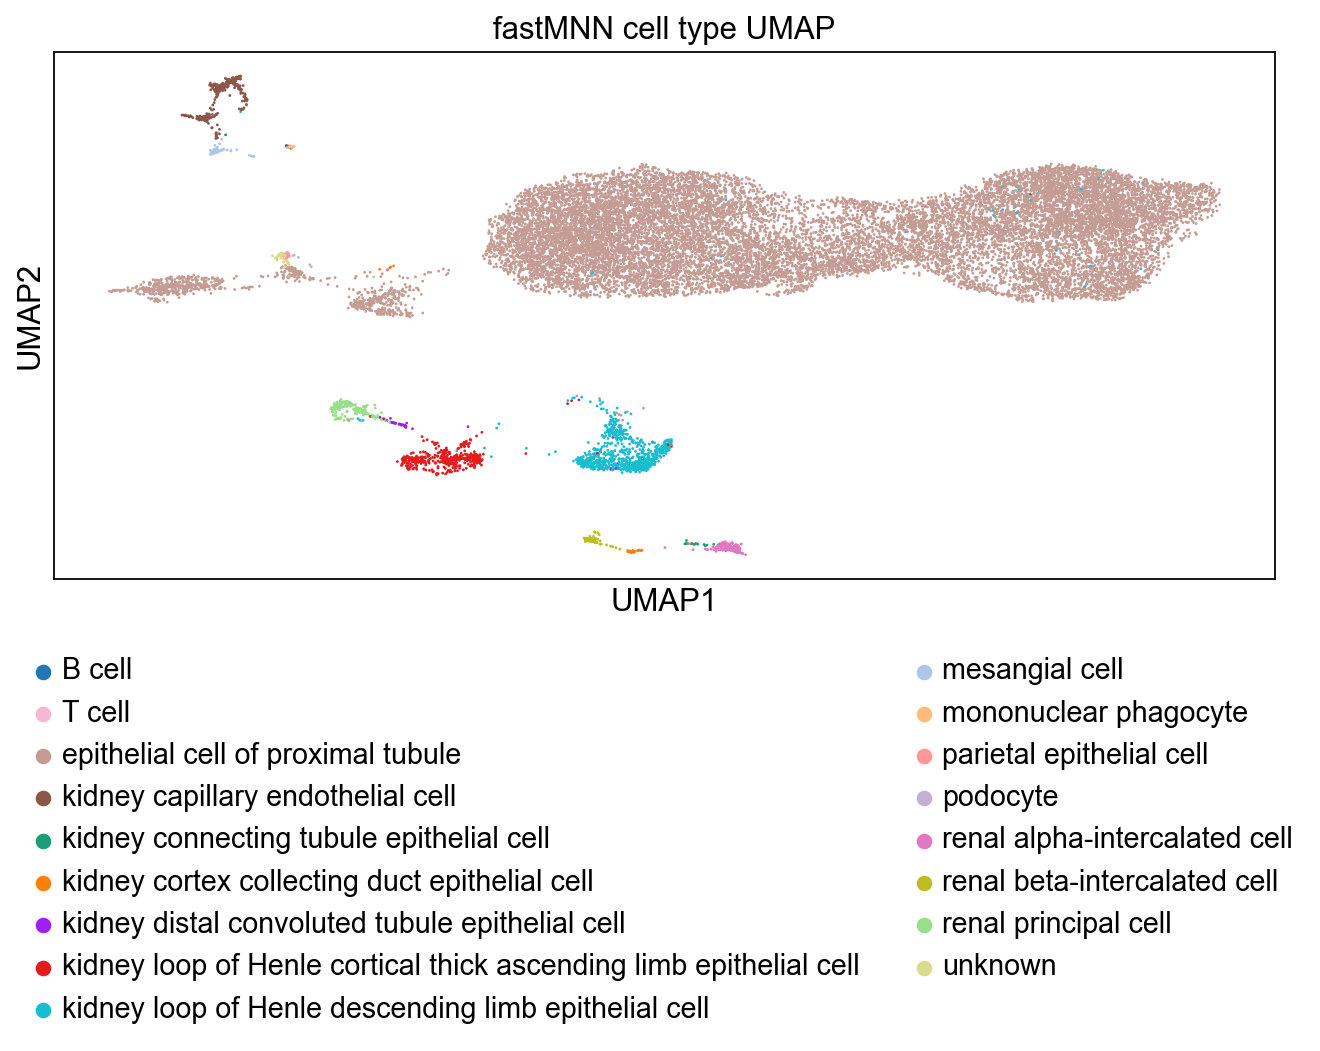

In [14]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(facecolor="white")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

adata_fastmnn.obs["sample_id"] = adata_fastmnn.obs["sample_id"].astype("category")
adata_fastmnn.obs["cell_type"] = adata_fastmnn.obs["cell_type"].astype("category")

batch_color_map = {
    "Total1": "#8dd3c7",
    "Total2": "#ffffb3",
    "Total3": "#bebada",
    "Total4": "#fb8072",
    "Total5": "#80b1d3",
    "Total6": "#fdb462",
    "Total7": "#b3de69",
    "Total8": "#bc80bd",
    "Total9": "#ccebc5"
}

celltype_color_map = {
    "B cell": "#1f77b4",
    "kidney cortex collecting duct epithelial cell": "#ff7f0e",
    "kidney connecting tubule epithelial cell": "#1b9e77",
    "kidney loop of Henle cortical thick ascending limb epithelial cell": "#e41a1c",
    "kidney distal convoluted tubule epithelial cell": "#a020f0",
    "kidney capillary endothelial cell": "#8c564b",
    "renal alpha-intercalated cell": "#e377c2",
    "renal beta-intercalated cell": "#bcbd22",
    "kidney loop of Henle descending limb epithelial cell": "#17becf",
    "mesangial cell": "#aec7e8",
    "mononuclear phagocyte": "#ffbb78",
    "renal principal cell": "#98df8a",
    "parietal epithelial cell": "#ff9896",
    "podocyte": "#c5b0d5",
    "epithelial cell of proximal tubule": "#c49c94",
    "T cell": "#f7b6d2",
    "unknown": "#dbdb8d"
}

adata_fastmnn.uns["sample_id_colors"] = [
    batch_color_map[x] for x in adata_fastmnn.obs["sample_id"].cat.categories
]

adata_fastmnn.uns["cell_type_colors"] = [
    celltype_color_map[x] for x in adata_fastmnn.obs["cell_type"].cat.categories
]

sc.pp.neighbors(adata_fastmnn, use_rep="X_fastmnn")
sc.tl.umap(adata_fastmnn, min_dist=0.3)
sc.tl.leiden(adata_fastmnn, resolution=0.5)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_fastmnn,
    color="sample_id",
    title="fastMNN sample UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("fastMNN sample UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc.pl.umap(
    adata_fastmnn,
    color="cell_type",
    title="fastMNN cell type UMAP",
    ax=ax,
    show=False,
    frameon=True
)

ax.set_title("fastMNN cell type UMAP", color="black")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("black")

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.get_texts()]
legend.remove()

new_legend = ax.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

for text in new_legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()